<a href="https://colab.research.google.com/github/h186487/DAT158MLSopp/blob/main/notebooks/01_eda_cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01: EDA og cleaning

**Prosjekt:** DAT158, ML Assignment 2 (sopp: giftig eller spiselig)

**Datasett:** UCI Mushroom (dataset 73), ca. 8100 sopper beskrevet med 22 kategoriske features. Label: giftig (`p`) eller spiselig (`e`).

Denne notebooken henter datasettet, undersøker datakvaliteten, utforsker hvilke features som skiller klassene, renser dataene og deler dem i trenings- og testsett. Resultatet er `train.csv` og `test.csv`, som brukes videre i modelleringen.

**Konvensjoner:** `poisonous` = 1 betyr giftig (positiv klasse), 0 betyr spiselig. Manglende verdier kodes som `"unknown"`. `random_state=42` brukes overalt.

## 1. Hent data

In [9]:
!pip install ucimlrepo

In [10]:
from ucimlrepo import fetch_ucirepo
import pandas as pd

m = fetch_ucirepo(id=73)
X, y = m.data.features, m.data.targets


## 2. Første oversikt

In [11]:
print(X.shape)
print(list(X.columns))
print(y.value_counts(normalize=True))
X.head()

(8124, 22)
['cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor', 'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color', 'stalk-shape', 'stalk-root', 'stalk-surface-above-ring', 'stalk-surface-below-ring', 'stalk-color-above-ring', 'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number', 'ring-type', 'spore-print-color', 'population', 'habitat']
poisonous
e            0.517971
p            0.482029
Name: proportion, dtype: float64


,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,x,s,n,t,p,f,c,n,k,e,...,s,w,w,p,w,o,p,k,s,u
1,x,s,y,t,a,f,c,b,k,e,...,s,w,w,p,w,o,p,n,n,g
2,b,s,w,t,l,f,c,b,n,e,...,s,w,w,p,w,o,p,n,n,m
3,x,y,w,t,p,f,c,n,n,e,...,s,w,w,p,w,o,p,k,s,u
4,x,s,g,f,n,f,w,b,k,t,...,s,w,w,p,w,o,e,n,a,g


Datasettet har 8124 rader og 22 kategoriske features. Klassene er nesten balansert ca. 52% spiselige og ca. 48% giftige. Det er dermed ikke behov for spesiell håndtering av klasseubalanse.

## 3. Datakvalitet

In [12]:
print("NaN per kolonne:")
print(X.isna().sum()[lambda s: s > 0])

print("\n'?' per kolonne:")
print((X == "?").sum()[lambda s: s > 0])

print("\nKolonner med færrest unike verdier:")
print(X.nunique().sort_values().head())

print("\nAntall duplikater:", X.duplicated().sum())

NaN per kolonne:
stalk-root    2480
dtype: int64

'?' per kolonne:
Series([], dtype: int64)

Kolonner med færrest unike verdier:
veil-type       1
bruises         2
gill-spacing    2
gill-size       2
stalk-shape     2
dtype: int64

Antall duplikater: 0


- Manglende verdier: `stalk-root` har 2480 manglende verdier.
  Ingen andre kolonner har manglende verdier, og det finnes ingen verdier kodet som `?`.
- Konstant kolonne: `veil-type` har kun én unik verdi og gir ingen informasjon, så den droppes.
- Duplikater: 0, så det er ingen risiko for leakage mellom train og test.

## 4. Utforsking (EDA)

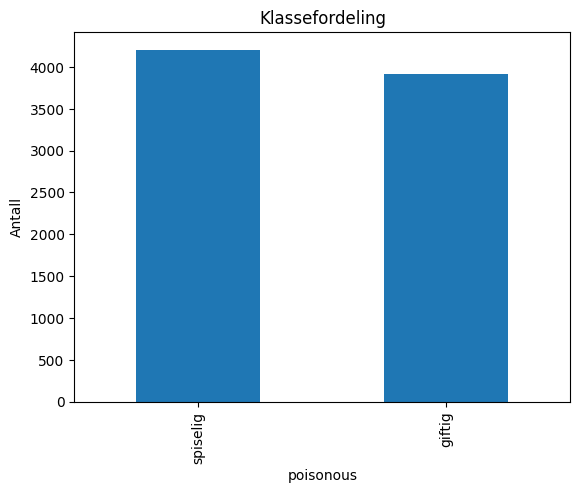

In [13]:
import matplotlib.pyplot as plt

y_bin = (y.iloc[:, 0] == "p").astype(int)   # 1 = giftig, 0 = spiselig

y_bin.value_counts().rename({0: "spiselig", 1: "giftig"}).plot.bar(title="Klassefordeling")
plt.ylabel("Antall")
plt.show()

--- odor ---
      antall  andel_giftige
odor                       
a        400          0.000
l        400          0.000
n       3528          0.034
c        192          1.000
f       2160          1.000
m         36          1.000
p        256          1.000
s        576          1.000
y        576          1.000


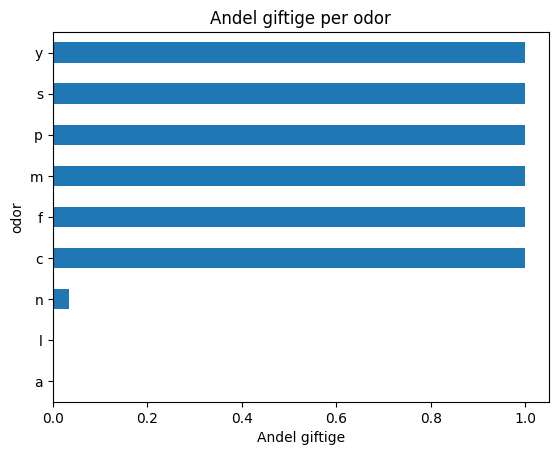

--- spore-print-color ---
                   antall  andel_giftige
spore-print-color                       
b                      48          0.000
o                      48          0.000
u                      48          0.000
y                      48          0.000
n                    1968          0.114
k                    1872          0.120
w                    2388          0.759
h                    1632          0.971
r                      72          1.000


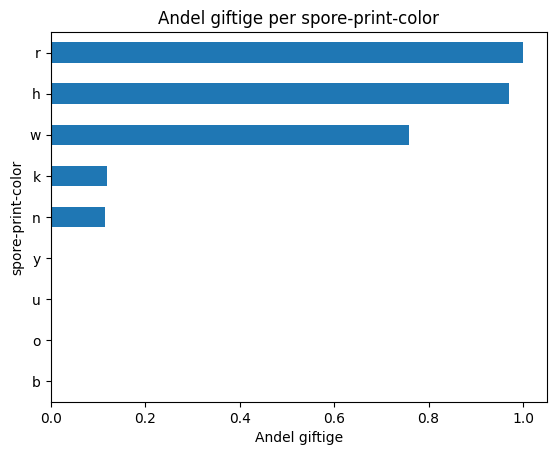

--- gill-size ---
           antall  andel_giftige
gill-size                       
b            5612          0.301
n            2512          0.885


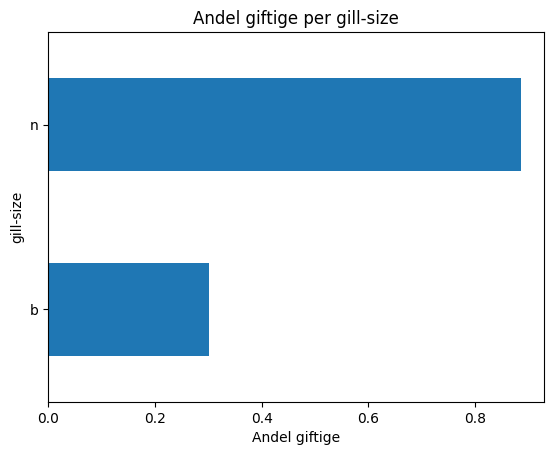

In [17]:
df = X.copy()
df["poisonous"] = y_bin

for col in ["odor", "spore-print-color", "gill-size"]:
    # tabell med eksakte tall
    stats = df.groupby(col)["poisonous"].agg(antall="count", andel_giftige="mean").round(3)
    print(f"--- {col} ---")
    print(stats.sort_values("andel_giftige"))

    # figur (samme data som i tabellen)
    stats["andel_giftige"].sort_values().plot.barh(title=f"Andel giftige per {col}")
    plt.xlabel("Andel giftige")
    plt.show()

`odor` er den mest informative featuren alene. Seks lukttyper (fishy, spicy, pungent, musty, foul, creosote)
gir 100% giftige, mens anis og mandel gir 0%. Kategorien "ingen lukt" er imidlertid stor og inneholder
ca. 3% giftige sopper, så `odor` alene er ikke et trygt kriterium: det gir false negatives.
`spore-print-color` skiller moderat (grønn og sjokoladebrun overveiende giftige, hvit ca. 76%), og
`gill-size` skiller svakere (narrow ca. 89% giftige, broad ca. 30%). Ingen enkeltfeature er tilstrekkelig,
noe som motiverer å undersøke hvilke kombinasjoner av features som gir høy recall.

## 5. Cleaning

In [21]:
X_clean = X.replace("?", "unknown").fillna("unknown")

# dropp konstante kolonner
const_cols = [c for c in X_clean.columns if X_clean[c].nunique() <= 1]
print("Droppes:", const_cols)
X_clean = X_clean.drop(columns=const_cols)

print(X_clean.shape)
X_clean.head()

Droppes: ['veil-type']
(8124, 21)


,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,x,s,n,t,p,f,c,n,k,e,...,s,s,w,w,w,o,p,k,s,u
1,x,s,y,t,a,f,c,b,k,e,...,s,s,w,w,w,o,p,n,n,g
2,b,s,w,t,l,f,c,b,n,e,...,s,s,w,w,w,o,p,n,n,m
3,x,y,w,t,p,f,c,n,n,e,...,s,s,w,w,w,o,p,k,s,u
4,x,s,g,f,n,f,w,b,k,t,...,s,s,w,w,w,o,e,n,a,g


- Manglende verdier (`stalk-root`) er erstattet med `"unknown"` i stedet for å fjerne radene. Det bevarer all data,
  og samme verdi brukes for "Vet ikke" i appen.
- `veil-type` er droppet siden den er konstant.
- Ingen duplikater ble funnet, så ingen rader er fjernet. Datasettet har nå 8124 rader og 21 features.

## 6. Train/test-split

In [16]:
from sklearn.model_selection import train_test_split

Xtr, Xte, ytr, yte = train_test_split(
    X_clean, y_bin, test_size=0.2, stratify=y_bin, random_state=42)

Xtr.assign(poisonous=ytr).to_csv("train.csv", index=False)
Xte.assign(poisonous=yte).to_csv("test.csv", index=False)

print(Xtr.shape, Xte.shape)
print(ytr.mean(), yte.mean())

(6499, 21) (1625, 21)
0.4820741652561933 0.48184615384615387


Dataene er delt 80/20 (6499 trening, 1625 test), stratifisert på label, med random_state=42.
Andelen giftige er 48,2 % i begge sett. Testsettet brukes kun til endelig evaluering.
Filene er lagret som train.csv og test.csv.